
# Bayesian Hierarchical ARX Hurdle Model for Gravity Migration

#### Brouillon (daté du 26 mars) pour présenter la méthode générale, les paramètres, la hiérarchie, l'hétéroscédasticité, quelques résultats. 
### Une version propre sera disponible la semaine prochaine, qui s'intègrera au rapport.




**A. Hurdle (Logit)** : 
$\text{logit}(P(\text{flow}>0)) = \alpha_d + X_h \beta_h + \beta_{lag} \text{is\_mig\_lag}$

**X_h**= (frontière_commune_ij, log(distance_ij) ).  
**B. Volume (ARX)** : 
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t} + \phi_d (\text{lag} - \mu_{d,t-1}), \sigma_d)$$
$$\mu_{d,t} = \alpha_{V,d} + X \beta_{\text{grav}} + \beta_{\text{gdp}} \log(\text{gdpcap\_o}) + \beta_{\text{rich}} \text{is\_rich\_o}$$

**X**: toutes les variables du modèle de gravité de Welch&raftery.  
**is_rich_o:** est ce que le pays de départ dépasse le seuil de 18,000$ de PIB/tête (seuil détecter par Random Forest)  


# Hamiltonian Monte Carlo: 
(absolument crucial, descendre une pente est bien plus rapide à converger qu'un Metropolis aveugle)

- Le paysage énergétique est un espace de paramètres postériors, chaque position est un vecteur de paramètres (de dimension 90 000 environ, voir partie Paramètres ci-dessous). Si on travaille en -log-vraisemblance: les puits sont les zones de fortes probabilités. 

- À chaque itération $s$ (de 1 à iter_sampling): Impulsion aléatoire, puis la fin du mouvement régit par les équations de Hamilton jusqu'à la position x. 

- A la position x, Stan possède un set de paramètres. Il calcule alors mécaniquement :$$\mu_{d,t}^{(s)} = \alpha_{V,d}^{(s)} + X \beta_{\text{grav}}^{(s)} + \beta_{\text{gdp}}^{(s)} \log(\text{gdpcap\_o}) + \beta_{\text{rich}}^{(s)} \text{is\_rich\_o} $$


Modèle hiérarchique hétérosced: (dans *transformed parameters*)

$\alpha_{V,d} = \mu_{intercept} + \tau_{\mu} \times \mu_{raw}[d]$ *(intercept: moyenne sur le meme cluster)*

$\phi_d = \tanh(\phi_{global\_raw} + \tau_{\phi} \times \phi_{raw}[d])$ *(raw: chaque couloir possède son raw unique, son ADN, générée d'un prior)*  
Rq: ne pas laisser Stan tirer de mu_d ~ normal(mu_intercept, tau_mu) car il resterait bloqué si tau_mu proche de zéro )

$\sigma_d = \sigma_{cluster}[continent] \times \exp(\tau_{\sigma} \times \sigma_{raw}[d])$

Stan prend les raw tirés du bruit et les multiplie par les $\tau$ pour construire l'état de chaque couloir : $\alpha_{V,d}^{(s)}$, $\phi_d^{(s)}$ et $\sigma_d^{(s)}$.
Il assemble tout ça avec les variables géoécononomiques ($X$, PIB, etc.) pour calculer le $\mu_{d,t}^{(s)}$.


Puis, il utilise cette valeur pour évaluer la distance par rapport aux vrais flux via la loi Volume:
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t}^{(s)} + \phi_d^{(s)} (\text{lag} - \mu_{d,t-1}^{(s)}), \sigma_d^{(s)}) $$

L'acceptation (Metropolis-Hastings) à la fin du mouvement: Stan vérifie si l'énergie totale a été conservée. Il applique la règle d'acceptation :
$$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$
(isomorphisme entre conservation de l'énergie et maximisation de la proba a posteriori plutôt, càd vraisemblance + priors. C'est un compromis entre ce que disent les données et les priors)

Si la nouvelle position est cohérente avec les données ($\Delta H =0$) , il l'accepte et inscrit les paramètres dans des matrices.  
Sinon, il rejette la proposition et reste sur la valeur précédente.

**paramètres globaux:** vecteurs de 1200 composantes à la fin du sampling
- mu : matrice qui contient les log(flow), 1200* nombre de couloirs
- sigma_cluster : dimension 1200x6
- beta_grav: 1200x20 (20 variables explicatives)
- effets dyadiques: matrices de 1200*nombres de couloirs



**C. Variance (Geo)** : 
$\sigma_d \sim \text{HalfNormal}(\sigma_{\text{cluster}}[\text{continent\_origine}[d]])$ *(alternative à InverseGamma)*


# Prédiction : 

une fois stocké toutes les matrices de paramètres, numpy prend la relève et calcule bêtement toutes les formules pour chaque itération
(par ex $$\mu_{d,t}^{(1)} = \alpha_d^{(1)} + X \beta^{(1)}$$ pour l'itération s=1). Il fait ça pour les 1200 itérations, pour chaque couloir. 

**On a donc chains * iter / thin * dyades prédictions.**  
**On prend la médiane de ces prédictions pour chaque couloir, pour minimiser l'erreur MAE.**

# MÉTHODOLOGIE 
*(pour rapport ou annexe)*

1) Couplage entre bayésien & Machine Learning (Partie ARX et Variance Géo).  
Ce modèle bayésien intègre les découvertes faites par le Random Forest :
- Saut brutal de migration autour de 18 000 $ de PIB/hab. 
  Encodé par la variable indicatrice 'is_rich_o' 
- Interaction 'log_D_ij * LB_ij' (distance * frontière commune) 
  dont l'importance a été découverte par un PDP 2D du Random forest, et prouvée par régression linéaire 
- Correction des résidus : La cartographie des erreurs des XGBoost & RF montrait une incertitude 
  systématique (sous/sur-estimation) en Afrique, et un peu en Asie/Amerique latine. L'hétéroscédasticité 
  géographique modélise cette variance propre à chaque continent (à affiner par zone géo plus précise?)


2) Gestion des zéros (partie Hurdle). 
Le problème: il y a beaucoup de flux nuls, et on ne peut ni les enlever de l'analyse, ni faire log(x+1) (scientifiquement mauvais)
Forcer un pic à zéro pour loi Normale (qui ne sait faire que une cloche, et pas une cloche + un pic à zéro) fait diverger 
la variance et les chaines de Markov. 
Le modèle Hurdle: regression logistique (Bernoulli); si et seulement si le couloir est ouvert (>0) => équation de gravité ARX. 
Si non (flux=0) STAN s'arrête là et prédit 0 migrant (dans la phase de prédiction)



3) intuition physique de STAN (Hamiltonian Monte Carlo). 
Contrairement aux auteurs qui utilisaient le Gibbs sampling via JAGS, Stan utilise HMC. 
 HMC utilise la mécanique hamiltonienne pour explorer le paysage des posteriors bayésiens, (trajectoire guidée par lmes équations de Hamilton)
avec une étape d'acceptation Metropolis-Hastings à la fin selon $$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$ 
pour corriger les erreurs numériques sur la conservation de l'énergie ($$\Delta H =0$$) liées à la discrétisation de temporelle. 


Une exploration entière par Metropolis (marche aléatoire) aurait été inefficace et incroyablement lente pour autant de paramètres

4) Stabilité géométrique.  
Pour éviter que l'algorithme ne se coince (entonnoir), au lieu d'échantillonner 
directement α_d ~ N(μ, τ), on échantillonne un bruit pur ε ~ N(0,1), puis on calcule 
 α_d = μ + τ·ε. Cela détruit les corrélations pathologiques durant le HMC 

5) Approche dyadique.  
Mon modèle est purement "Dyadique" contrairement à celui de Ishagh (Inflow/Outflow). Ce code modélise chaque couloir de migration.  
On pourra comparer les deux approches in fine. 

6) Évaluation Out-Of-Sample.  
Le modèle est entraîné sur la période 1990-2010 et testé en prédiction pure sur 2015. 
Pour évaluer la qualité de la prédiction, on retient la MAE (Erreur absolue en nombre d'humains réels) et le MAPE comme Welch&raftery pour pouvoir comparer nos résultats   
(**attention:** Welch&raftery divisent par y+1 leur erreur MAPE pour éviter la division par zéro, ce qu'on fait donc aussi)

# Commentaires de résultats
**Médiane vs Espérance (Le problème des 25M) :**  
Le modèle est évalué en MAE. L'espérance $exp(\mu + \sigma^2/2)$ minimise la MSE mais donne des prédictions délirantes quand la variance explose. (Stan gonfle la variance future avec l'inflation $1+\phi^2$ car il y a l'incertitude passée PLUS(+) l'incertitude nouvelle à considérer).  
Un gros sigma donne vite une prédiction max absurde à 25 millions de migrants pour la route MEX-USA par ex. On utilise donc la médiane $exp(\mu)$ comme minimiseur naturel de la norme L1 (MAE). 

#### De toute façon, le choix le plus "économétrique (pour la décision publique)" pour des flux migratoires, c'est de s'intéresser à l'erreur en nombre de migrants (pas en carré de migrants).


**Métrique ROC :**  
Pour le seuil d'ouverture Hurdle, on utilise la courbe ROC plutôt que l'Accuracy pure. Le choix est arbitraire et les deux cas reviennent au même à 0,03% près de précision: en effet il n'y a pas de classe majoritaire dans nos données (49% de zéros). 

**Coverage & IC :**    
L'hétéroscédasticité marche super bien ici. Pour un couloir européen stable, le modèle coupe les 2.5% extrêmes et donne un IC étroit (+/- 30%). Pour un couloir asiatique instable, ça s'écarte beaucoup plus (jusqu'à +150% de largeur). Le but ultime c'est que la vraie valeur tombe dans l'IC dans 95% des cas.

**Comparaison Welch & Raftery :**    
En plus de la MAE et du Log-MAE (parfait pour les ordres de grandeurs), on suit le WMAPE et le "MAPE+1" (Eq 4 du papier de Welch) pour pouvoir faire un vrai benchmark face à eux sans que la division par zéro des petits couloirs ne fasse crasher le calcul.



# simulation 140 pays 27 mars: erreur MAE à 1300 (on a diviser l'erreur MAE sur 70 pays par 7 !)
## Gros problème de capacité prédictive des flux entre 1 et 10 (visible sur nuage de point). 
Idée: 

$Y = 0$ $\rightarrow$ Bernoulli
$Y \in [1, 10]$ $\rightarrow$ Modèle B
$Y > 10$ $\rightarrow$ Log-Normal

ou alors trop *ad-hoc* ?


# Paramètres: 

Partie Hurdle ($D_h$) : Un paramètre alpha_raw par dyade. Cela fait 190 * 189 dimensions. 
Partie Volume ($D_v$) : mu_raw (l'intercepte du volume), phi_raw (l'inertie AR1 propre au couloir) et sigma_raw par dyade. Environ 50% des dyades ont du volume, donc 0.5 * 190 * 189 * 3 dimensions environ. 

- Gravité & Hurdle : Les vecteurs $\beta_{h}$ (3) et $\beta_{grav}$ (~20).
- Hyper-paramètres : Les moyennes et variances globales (mu_intercept, sigma_global, phi_global, tau_alpha, tau_mu, tau_sigma, tau_phi).
- Clusters : Les variances par continent sigma_cluster (6 dimensions).


# Davantages de commentaires des résultats et de la méthode au fil du notebook, et en commentaire dans les cellules de code. 

# changement de paradigme, réunion 26 Mar

- toujours mu_ij propre à chaque dyade, simplement on calcule maintenant alpha_i propre à chaque pays, beta_j propre à chaque pays, et on additionne mu_ij=alpha_i + beta_j (coeff émission + coeff attraction). On passe de 190*189 paramètres inconnus à 2*190.
Pour une dyade vide, le modèle n'inventera plus un mu_ij absurde 

(modifier dans Stan les vecteurs de taille D (dyades) par des vecteurs de taille N_pays, modifier le bloc parameters, définir des priors, modifier l'equation dans model pour intégrer ces effets.)
Dans python, modifier stan_data, au lieu de fournir un dyad_id il faudra un orig_id et dest_id, et Stan additionnera dans model 

- évaluer et comparer les modèles. AIC/BIC surestimeraient la complexité du modèle ? DIC trop simpliste ? PSIS-LOO est le standard moderne ?(Leave One Out cross validation, cf cours ML & Econometrics 1)
Coût CPU: negligeable. Coût RAM/Disque colossal.
Mettre la generation de log_lik de Stan avec interrupteur ==1 à mettre à 0 pour la production de figures et prédictions, et 1 pour la comparaison de modèles (lourds à simuler)

In [1]:
# Installation des bibliothèques non classiqus
!pip install pycountry_convert arviz cmdstanpy

# compilation de Stan
import cmdstanpy
cmdstanpy.install_cmdstan()

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CmdStan install directory: /home/onyxia/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


True

# stratégie à faire le 27 mars: 

### enrichissement du Hurdle en variables;
 rechercher les "cygnes noirs" (les derniers 3,8% de precision du Hurdle).  

variables retenues: (le but n'est pas de mettre TOUTES les variables de gravité. Le Hurdle s'intéresse à l'*existence* du couloir, pas à son *volume*. Les variables les plus pertinentes: OL_ij et COL_ij (passé historique colonial et langue officielle commune) ; log_pop_d et log_pop_o (si les deux pays sont massifs, alors il y a certainement un flux) ) ; log_gdp_d et IMR (indice de richesse du pays d'arrivée).   

### beta_lag_global à passer en continental; 

et montrer que chaque continent a un coeff très différent pour valider l'approche. 



In [2]:
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pycountry_convert as pc
from cmdstanpy import CmdStanModel
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve  

warnings.filterwarnings('ignore')
np.random.seed(42)

In [3]:






# Chargement & filtrage pays




DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)



# Sélecteur : 1 (30 pays), 2 (70 pays), 3 (110 pays), 4 (140 pays), 5 (190 pays / Full)
CHOIX_ECHANTILLON = 5

# listes pré-définies 
L_30 = ['FRA', 'USA', 'DEU', 'GBR', 'JPN', 'CAN', 'AUS', 'ITA', 'DZA', 'MAR', 'ZAF', 'NGA', 'EGY', 'SEN', 'CIV', 'KEN', 'MEX', 'BRA', 'ARG', 'COL', 'CHL', 'PER', 'CHN', 'IND', 'TUR', 'IDN', 'KOR', 'SAU', 'VNM', 'THA']

L_70 = L_30 + ['ESP', 'CHE', 'SWE', 'NLD', 'BEL', 'NOR', 'AUT', 'PRT', 'NZL', 'RUS', 'POL', 'RWA', 'COD', 'ETH', 'TUN', 'MLI', 'GHA', 'AGO', 'SDN', 'CMR', 'TZA', 'UGA', 'MOZ', 'VEN', 'CUB', 'ECU', 'DOM', 'CRI', 'BOL', 'URY', 'PAK', 'PHL', 'BGD', 'IRQ', 'ARE', 'IRN', 'ISR', 'MYS', 'SGP', 'KAZ']

L_110 = L_70 + ['DNK', 'FIN', 'IRL', 'CZE', 'GRC', 'HUN', 'ROU', 'BGR', 'HRV', 'UKR', 'SRB', 'SOM', 'LBY', 'ZMB', 'ZWE', 'TCD', 'BFA', 'GIN', 'MDG', 'MWI', 'BDI', 'TGO', 'HTI', 'SLV', 'GTM', 'HND', 'PRY', 'NIC', 'PAN', 'MMR', 'SYR', 'AFG', 'YEM', 'LBN', 'UZB', 'JOR', 'LKA', 'NPL', 'KHM', 'OMN']

L_140 = L_110 + ['SVK', 'SVN', 'EST', 'LVA', 'LTU', 'ISL', 'CYP', 'LUX', 'ALB', 'BLR', 'BEN', 'SLE', 'LBR', 'MRT', 'CAF', 'COG', 'GAB', 'NAM', 'NER', 'JAM', 'TTO', 'BHS', 'BRB', 'BLZ', 'QAT', 'LAO', 'KWT', 'MNG', 'TJK', 'KGZ']  

if CHOIX_ECHANTILLON == 5:
    # Option 5 : Utilisation de la totalité du Df
    df = df_main[df_main['orig'] != df_main['dest']].copy()
else:
    
    map_listes = {1: L_30, 2: L_70, 3: L_110, 4: L_140}
    cible = map_listes[CHOIX_ECHANTILLON]
    
    df = df_main[
        df_main['orig'].isin(cible) & 
        df_main['dest'].isin(cible) & 
        (df_main['orig'] != df_main['dest'])
    ].copy()

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
N_pays = df['orig'].nunique()
print(f"Extraction et simulation sur : {N_pays} pays.")




Extraction et simulation sur : 190 pays.


In [4]:
# Clustering géographique (EXOGENE au modèle et PUBLI: ISO-3166 alpha-3. Inattaquable)

# à réfléchir: clustering plus précis (sub-divisions ONU là encore public type Asie de l'Est, Asie du Sud...). très intéressant, et cite une source onusienne.
# Attention tout de même : beaucoup de sous-régions ONU, s'assurer que chaque sous région possède assez de dyade pour ne pas laisser le prior laissé à lui même. si pas assez e dyades, les fusionner en une plos grosse région, facilement défendable. 
# OU ALORS: laisser le modèle clusteriser par lui même (plus original)

"""

def get_continent_id(iso3_code):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        continent = pc.country_alpha2_to_continent_code(iso2)
        return {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}.get(continent, 7)
    except Exception:
        return 7

df['continent_orig'] = df['orig'].apply(get_continent_id)
K_clusters = 6

"""



"\n\ndef get_continent_id(iso3_code):\n    try:\n        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)\n        continent = pc.country_alpha2_to_continent_code(iso2)\n        return {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}.get(continent, 7)\n    except Exception:\n        return 7\n\ndf['continent_orig'] = df['orig'].apply(get_continent_id)\nK_clusters = 6\n\n"

In [5]:

# Clustering géographique — Sous-régions ONU (Standard M49)

ISO3_TO_M49_SUBREGION = {
    # --- Europe ---
    'DNK': 11, 'EST': 11, 'FIN': 11, 'ISL': 11, 'IRL': 11, 'LVA': 11, 'LTU': 11, 'NOR': 11, 'SWE': 11, 'GBR': 11,
    'ALB': 12, 'AND': 12, 'BIH': 12, 'HRV': 12, 'GRC': 12, 'ITA': 12, 'MLT': 12, 'MNE': 12, 'MKD': 12, 'PRT': 12, 'SRB': 12, 'SVN': 12, 'ESP': 12,
    'AUT': 13, 'BEL': 13, 'FRA': 13, 'DEU': 13, 'LIE': 13, 'LUX': 13, 'MCO': 13, 'NLD': 13, 'CHE': 13,
    'BLR': 14, 'BGR': 14, 'CZE': 14, 'HUN': 14, 'POL': 14, 'MDA': 14, 'ROU': 14, 'RUS': 14, 'SVK': 14, 'UKR': 14,
    # --- Afrique ---
    'DZA': 15, 'EGY': 15, 'LBY': 15, 'MAR': 15, 'SDN': 15, 'TUN': 15, 'ESH': 15,
    'BEN': 16, 'BFA': 16, 'CPV': 16, 'CIV': 16, 'GMB': 16, 'GHA': 16, 'GIN': 16, 'GNB': 16, 'LBR': 16, 'MLI': 16, 'MRT': 16, 'NER': 16, 'NGA': 16, 'SEN': 16, 'SLE': 16, 'TGO': 16,
    'BDI': 17, 'COM': 17, 'DJI': 17, 'ERI': 17, 'ETH': 17, 'KEN': 17, 'MDG': 17, 'MWI': 17, 'MUS': 17, 'MOZ': 17, 'RWA': 17, 'SYC': 17, 'SOM': 17, 'SSD': 17, 'TZA': 17, 'UGA': 17, 'ZMB': 17, 'ZWE': 17,
    'AGO': 18, 'CMR': 18, 'CAF': 18, 'TCD': 18, 'COD': 18, 'COG': 18, 'GNQ': 18, 'GAB': 18, 'STP': 18,
    'BWA': 19, 'LSO': 19, 'NAM': 19, 'ZAF': 19, 'SWZ': 19,
    # --- Amériques ---
    'CAN': 21, 'MEX': 21, 'USA': 21,
    'BLZ': 22, 'CRI': 22, 'SLV': 22, 'GTM': 22, 'HND': 22, 'NIC': 22, 'PAN': 22,
    'ATG': 23, 'BHS': 23, 'BRB': 23, 'CUB': 23, 'DMA': 23, 'DOM': 23, 'GRD': 23, 'HTI': 23, 'JAM': 23, 'KNA': 23, 'LCA': 23, 'VCT': 23, 'TTO': 23, 'ABW': 23, 'PRI': 23,
    'ARG': 24, 'BOL': 24, 'BRA': 24, 'CHL': 24, 'COL': 24, 'ECU': 24, 'GUY': 24, 'PRY': 24, 'PER': 24, 'SUR': 24, 'URY': 24, 'VEN': 24,
    # --- Asie ---
    'CHN': 30, 'HKG': 30, 'JPN': 30, 'KOR': 30, 'MAC': 30, 'MNG': 30, 'PRK': 30,
    'AFG': 34, 'BGD': 34, 'BTN': 34, 'IND': 34, 'IRN': 34, 'MDV': 34, 'NPL': 34, 'PAK': 34, 'LKA': 34,
    'BRN': 35, 'KHM': 35, 'IDN': 35, 'LAO': 35, 'MYS': 35, 'MMR': 35, 'PHL': 35, 'SGP': 35, 'THA': 35, 'TLS': 35, 'VNM': 35,
    'ARM': 145, 'AZE': 145, 'BHR': 145, 'CYP': 145, 'GEO': 145, 'IRQ': 145, 'ISR': 145, 'JOR': 145, 'KWT': 145, 'LBN': 145, 'OMN': 145, 'QAT': 145, 'SAU': 145, 'PSE': 145, 'SYR': 145, 'TUR': 145, 'ARE': 145, 'YEM': 145,
    'KAZ': 143, 'KGZ': 143, 'TJK': 143, 'TKM': 143, 'UZB': 143,
    # --- Océanie ---
    'AUS': 53, 'FJI': 53, 'NZL': 53, 'PNG': 53, 'SLB': 53, 'VUT': 53, 'WSM': 53, 'TON': 53, 'KIR': 53, 'FSM': 53, 'GUM': 53, 'NCL': 53, 'PYF': 53,
}

SUBREGION_LABELS = {
    11: 'Europe du Nord', 12: 'Europe du Sud', 13: "Europe de l'Ouest", 14: "Europe de l'Est",
    15: 'Afrique du Nord', 16: "Afrique de l'Ouest", 17: "Afrique de l'Est", 18: 'Afrique Centrale', 19: 'Afrique Australe',
    21: 'Amerique du Nord', 22: 'Amerique Centrale', 23: 'Caraibes', 24: 'Amerique du Sud',
    30: "Asie de l'Est", 34: 'Asie du Sud', 35: 'Asie du Sud-Est',
    143: 'Asie Centrale', 145: "Asie de l'Ouest", 53: 'Oceanie', 99: 'Non classifie'
}

# 1. Mapping M49 brut et indexation stricte (1..K)
df['m49_brut'] = df['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
_UNIQUE_M49_PRESENT = sorted(df['m49_brut'].unique())
_M49_TO_STAN = {m49: i + 1 for i, m49 in enumerate(_UNIQUE_M49_PRESENT)}
stan_to_m49 = {v: k for k, v in _M49_TO_STAN.items()}

# 2. Application au DataFrame (maintien du nommage 'continent_orig' pour compatibilité)
df['continent_orig'] = df['m49_brut'].map(_M49_TO_STAN)
K_clusters = len(_M49_TO_STAN)

print(f"{K_clusters} clusters détectés")
# 3. Vérification des effectifs dyadiques (Uniquement sur couloirs ouverts)
SEUIL_FUSION = 30
df_actifs = df[df['flow'] > 0].copy()

# Création vectorielle temporaire pour le décompte (la vraie variable 'dyad' sera créée à la cellule suivante)
df_actifs['temp_dyad'] = df_actifs['orig'] + "_" + df_actifs['dest']

# Comptage des couloirs uniques
dyad_counts = df_actifs.groupby('continent_orig')['temp_dyad'].nunique().reset_index(name='n_dyades')
dyad_counts['label'] = dyad_counts['continent_orig'].apply(lambda i: SUBREGION_LABELS.get(stan_to_m49.get(i, 99), 'Inconnu'))
dyad_counts = dyad_counts.sort_values('n_dyades')

print("\nRépartition des dyades par cluster (K) :")
print(dyad_counts[['label', 'continent_orig', 'n_dyades']].to_string(index=False))

problematic = dyad_counts[dyad_counts['n_dyades'] < SEUIL_FUSION]
if not problematic.empty:
    print(f"\n[ALERTE] Clusters sous le seuil critique ({SEUIL_FUSION} dyades) :")
    print(problematic[['label', 'n_dyades']].to_string(index=False))


19 clusters détectés

Répartition des dyades par cluster (K) :
             label  continent_orig  n_dyades
     Asie Centrale              18       490
  Amerique du Nord              10       524
  Afrique Australe               9       679
   Afrique du Nord               5       775
 Amerique Centrale              11       804
     Asie de l'Est              14       813
  Afrique Centrale               8       865
       Asie du Sud              15      1122
          Caraibes              12      1138
 Europe de l'Ouest               3      1222
           Oceanie              17      1251
   Europe de l'Est               4      1324
   Asie du Sud-Est              16      1342
   Amerique du Sud              13      1455
     Europe du Sud               2      1478
    Europe du Nord               1      1550
  Afrique de l'Est               7      1747
Afrique de l'Ouest               6      1806
   Asie de l'Ouest              19      2127


à faire: renommer beta_lag_continental en beta_lag_m49 et revoir l'approche bayésienne hiéarachique sur beta_lag (beta_lag_raw et tau_beta_lag etc)

Régularisation rigide vers le prior si volume de dyades modérés, overfitting si trop peu de dyades. 
La hiérarchie permet d'apprendre à partir de TOUTES les dyades. 

In [6]:
# Features, lags et split train/test




df['is_migration'] = (df['flow'] > 0).astype(int)
df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)

SEUIL_LOG_GDP       = 2.9
df['is_rich_o']     = (df['log_gdpcap_o_lag'] > SEUIL_LOG_GDP).astype(float)

df['log_D_ij']      = np.log(df['D_ij'].replace(0, np.nan))
df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']

df['dyad']          = df['orig'] + "_" + df['dest']
df['is_mig_lag']    = df.groupby('dyad')['is_migration'].shift(1)
df['log_flow_lag']  = df.groupby('dyad')['log_flow'].shift(1)
df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

HURDLE_VARS = [
    'log_D_ij',       # 1. Distance
    'LB_ij',          # 2. Frontière commune
    'logD_times_LB',  # 3. Interaction
    'COL_ij',         # 4. Colonie
    'OL_ij',          # 5. Langue officielle
    'log_P_it',      # 6. Population Origine
    'log_P_jt',      # 7. Population Destination
    'log_gdpcap_d_lag'       # 8. PIB Destination
    # 'IMR_jt' # mortalité infantile. On teste juste avec le PIB pour l'instant, car risque de colinéarité. 
]
ML_VARS         = ['log_gdpcap_o_lag', 'is_rich_o']
GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt',
                    'urban_it', 'urban_jt', 'LA_i', 'LA_j']
GRAVITY_VARS_BIN = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij',
                    't_2000', 't_2000_sq', 'log_gdpcap_d_lag']

for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan))

X_VOL_COLS = [f'log_{v}' for v in GRAVITY_VARS_RAW] + GRAVITY_VARS_BIN + ML_VARS
K_grav, K_h = len(X_VOL_COLS), len(HURDLE_VARS)

df_train = df[df['year'] <= 2010].copy()
df_test  = df[df['year'] == 2015].copy()
df       = df_train  




In [7]:
# Séparation hurdle / volume



HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration', 'dyad', 'continent_orig']
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

# Remplacement de 'log_flow' par 'flow' pour la vraisemblance ZTNB
VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)


In [8]:
# Nettoyage exclusif de la covariable inertielle brute (sans centrage)
df_test['log_flow_lag_clean'] = (
    df_test['log_flow_lag']
    .fillna(0.0)
    .replace([np.inf, -np.inf], 0.0)
)

In [9]:

# Encodage dyades et standardisation




dyades_h  = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i+1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (df_hurdle.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
             .values.astype(int))

dyades_v  = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i+1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (df_volume.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
             .values.astype(int))

BINARY_COLS_VOL = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 'is_rich_o']
BINARY_COLS_HUR = ['LB_ij', 'COL_ij', 'OL_ij']

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)



In [10]:


# Préparation du jeu de test OOS




df_test['dyad']          = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']  = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v']= df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)

df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)

"""
df_test['continent_orig_fill'] = df_test['orig'].apply(get_continent_id)
df_test['continent_orig_fill'] = df_test['continent_orig_fill'].fillna(7).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values.astype(int)
"""

# Application du dictionnaire M49 sur le jeu de test
df_test['m49_brut'] = df_test['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))

# Projection sur l'indice Stan. En cas de pays inconnu en test, assignation au dernier cluster (sécurité)
df_test['continent_orig_fill'] = df_test['m49_brut'].map(_M49_TO_STAN).fillna(K_clusters).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values

log_flow_lag_test = df_test['log_flow_lag'].fillna(0.0).values
is_mig_lag_test   = df_test['is_mig_lag'].fillna(0.0).values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS,
                                     BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS,
                                     BINARY_COLS_HUR, fit_stats=stats_h)


In [11]:
# Nettoyage impératif des infinis (flux nuls passés en log)
df_hurdle = df_hurdle.replace([np.inf, -np.inf], np.nan).dropna(subset=HURDLE_REQUIRED)
df_volume = df_volume.replace([np.inf, -np.inf], np.nan).dropna(subset=VOLUME_REQUIRED)

# Vérification  (doit retourner 0)
print(f"Infinis dans Volume : {np.isinf(df_volume[X_VOL_COLS].values).sum()}")

Infinis dans Volume : 0


In [12]:
# réseau initial (avant perte temporelle ou vectorielle)
# On reconstruit la liste cible 
pays_cibles = set(cible) if CHOIX_ECHANTILLON != 5 else set(df_main['orig'].unique())

# réseaux post-filtrage
pays_hurdle_train = set(df_hurdle['orig'].unique()).union(set(df_hurdle['dest'].unique()))
pays_volume_train = set(df_volume['orig'].unique()).union(set(df_volume['dest'].unique()))
pays_test_oos     = set(df_test['orig'].unique()).union(set(df_test['dest'].unique()))


exclus_hurdle = sorted(pays_cibles - pays_hurdle_train)
exclus_volume = sorted(pays_cibles - pays_volume_train)
exclus_test   = sorted(pays_cibles - pays_test_oos)

# Audit
print(f" DIAGNOSTIC EXCLUSIONS SILENCIEUSES (Sur {len(pays_cibles)} pays initiaux)")
print(f"Pays perdus pour le modèle Hurdle (Train) : {len(exclus_hurdle)}")
print(exclus_hurdle)

print(f"\nPays perdus pour le modèle Volume (Train) : {len(exclus_volume)}")
print(exclus_volume)

print(f"\nPays perdus pour le jeu de Test (OOS 2015) : {len(exclus_test)}")
print(exclus_test)


# covariables responsables des NaN
print("\n ANALYSE VALEURS MANQUANTES ")
colonnes_cibles = list(set(HURDLE_VARS + X_VOL_COLS))


nan_counts = df[colonnes_cibles].isna().sum()
valeurs_manquantes = nan_counts[nan_counts > 0].sort_values(ascending=False)

if not valeurs_manquantes.empty:
    print(valeurs_manquantes)
else:
    print("Aucun NaN détecté dans les colonnes ici.")


 DIAGNOSTIC EXCLUSIONS SILENCIEUSES (Sur 190 pays initiaux)
Pays perdus pour le modèle Hurdle (Train) : 10
['COD', 'GUM', 'MNE', 'PRK', 'ROU', 'SDN', 'SOM', 'SRB', 'SSD', 'TLS']

Pays perdus pour le modèle Volume (Train) : 10
['COD', 'GUM', 'MNE', 'PRK', 'ROU', 'SDN', 'SOM', 'SRB', 'SSD', 'TLS']

Pays perdus pour le jeu de Test (OOS 2015) : 19
['ABW', 'COD', 'ERI', 'GUM', 'LBY', 'MNE', 'NCL', 'PNG', 'PRI', 'PRK', 'PYF', 'ROU', 'SDN', 'SOM', 'SRB', 'SSD', 'SYR', 'TLS', 'VEN']

 ANALYSE VALEURS MANQUANTES 
OL_ij               3454
COL_ij              3454
LB_ij               3454
log_D_ij            3454
logD_times_LB       3454
log_P_it            1736
log_urban_it        1736
LL_i                1736
log_IMR_it          1736
log_urban_jt        1736
log_PSR_i           1736
LL_j                1736
log_IMR_jt          1736
log_P_jt            1736
log_PSR_j           1736
log_LA_i            1736
log_LA_j            1736
log_gdpcap_o_lag     461
log_gdpcap_d_lag     461
dtype: int64


In [13]:



# Construction du dictionnaire Stan

stan_data = {
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    
    # Cible ZTNB (comptage entier strict, non centré)
    'flow'         : df_volume['flow'].astype(int).tolist(),
    
    # Covariable AR(1) sur échelle log brute
    'log_flow_lag' : df_volume['log_flow_lag'].astype(float).tolist(), 
    
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    'K_clusters'   : int(K_clusters),

    'do_ppc': 0,

    'N_test'            : int(len(df_test)),
    'dyad_id_test_h'    : df_test['dyad_id_test'].astype(int).tolist(),
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'X_h_test'          : X_test_h_std.tolist(),
    'is_mig_lag_test'   : is_mig_lag_test.tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    
    # Lag test sur échelle log brute nettoyée
    'log_flow_lag_test' : df_test['log_flow_lag_clean'].tolist(),
    
    'cluster_test_h'    : cluster_test_h.tolist(),
}

In [14]:
# Sampling Stan parameters

N_CHAINS = 4
PARALLEL_CHAINS = 4
ITER_SAMPLING = 1500
THIN = 4

N_DRAWS = ITER_SAMPLING // THIN

In [15]:


# Sampling Stan


STAN_FILE = "../STAN/HMC_ARX_NegBin_test.stan" 



binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)
    print(f"Binaire supprimé : {binary}")

os.makedirs("./stan_outputs", exist_ok=True)

model = CmdStanModel(stan_file=STAN_FILE)

# # 1. On cible UNIQUEMENT les échelles (tau) et paramètres globaux
# def custom_inits():
#     return {
#         'tau_alpha': 0.5,
#         'tau_mu': 0.5,
#         'tau_phi': 0.5,
#         'tau_sigma': 0.5,
#         'sigma_global': 0.5,
#         'phi_global_raw': 0.5
#     }

# # 2. On crée un dictionnaire par chaîne
# inits_dict = [custom_inits() for _ in range(N_CHAINS)]

fit = model.sample(
    data             = stan_data,
    chains           = N_CHAINS,
    parallel_chains  = PARALLEL_CHAINS,       
    iter_warmup      = 750,
    iter_sampling    = ITER_SAMPLING,
    save_warmup      = False,
    seed             = 42,
    inits            = 0,
    thin             = THIN,       
    adapt_delta      = 0.95,
    max_treedepth    = 10,
    show_progress    = True,
    output_dir       = "./stan_outputs"
)




# nomenclature dynamique

custom_prefix = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it"
renamed_csvs = []


for i, old_path in enumerate(fit.runset.csv_files):
    new_path = os.path.join("./stan_outputs", f"{custom_prefix}_chain{i+1}.csv")
    os.replace(old_path, new_path)  # os.replace  écraseme les runs précédents identiques
    renamed_csvs.append(new_path)


csv_files = renamed_csvs
print(f"Outputs sécurisés sous : {custom_prefix}_chain*.csv")




10:22:46 - cmdstanpy - INFO - compiling stan file /home/onyxia/work/ProjetStat/STAN/HMC_ARX_NegBin_test.stan to exe file /home/onyxia/work/ProjetStat/STAN/HMC_ARX_NegBin_test


Binaire supprimé : ../STAN/HMC_ARX_NegBin_test


10:22:56 - cmdstanpy - INFO - compiled model executable: /home/onyxia/work/ProjetStat/STAN/HMC_ARX_NegBin_test
10:22:58 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2250 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/2250 [00:01<41:59,  1.12s/it, (Warmup)]


chain 1:   4%|▍         | 100/2250 [25:08<9:02:05, 15.13s/it, (Warmup)]


chain 1:   9%|▉         | 200/2250 [31:14<4:46:07,  8.37s/it, (Warmup)]




chain 1:  13%|█▎        | 300/2250 [37:36<3:24:34,  6.29s/it, (Warmup)]


chain 1:  18%|█▊        | 400/2250 [42:32<2:33:23,  4.98s/it, (Warmup)]


chain 1:  22%|██▏       | 500/2250 [47:35<2:04:39,  4.27s/it, (Warmup)]


chain 1:  27%|██▋       | 600/2250 [51:40<1:40:30,  3.65s/it, (Warmup)]


chain 1:  31%|███       | 700/2250 [55:41<1:23:50,  3.25s/it, (Warmup)]



chain 1:  33%|███▎      | 751/2250 [58:25<1:21:00,  3.24s/it, (Sampling)]


chain 1:  38%|███▊      | 850/2250 [1:02:26<1:09:06,  2.96s/it, (Sampling)]



chain 1:  42%|████▏     | 


12:28:20 - cmdstanpy - INFO - CmdStan done processing.
12:28:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'HMC_ARX_NegBin_test.stan', line 137, column 2 to column 55)
	Exception: neg_binomial_2_log_lpmf: Log location parameter is -inf, but must be finite! (in 'HMC_ARX_NegBin_test.stan', line 164, column 4 to column 75)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'HMC_ARX_NegBin_test.stan', line 137, column 2 to column 55)
	Exception: neg_binomial_2_log_lpmf: Log location parameter is -inf, but must be finite! (in 'HMC_ARX_NegBin_test.stan', line 164, column 4 to column 75)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'HMC_ARX_NegBin_test.stan', line 137, column 2 to column 55)
	Exception: neg_binomial_2_log_lpmf: Log location parameter is inf, but must be finite! (in 'HMC_ARX_NegBin_test.stan', line 164, column 4 to column 75)
Exception: normal_

12:29:06 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 4 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Outputs sécurisés sous : ARX_190pays_4c_1500it_chain*.csv


Stan galère au début de la chaîne à 0%, puis le temps (en seconde/itération) diminue exponentiellement jusqu'à se stabiliser et rester constant vers 50% de la simulation.

In [16]:
# si perte de connexion à la cellule précédente: 
# csv_files=csv_files = [
#     "/home/onyxia/work/ProjetStat/notebooks/stan_outputs/ARX_190pays_4c_1500it_chain1.csv",
#     "/home/onyxia/work/ProjetStat/notebooks/stan_outputs/ARX_190pays_4c_1500it_chain2.csv",
#     "/home/onyxia/work/ProjetStat/notebooks/stan_outputs/ARX_190pays_4c_1500it_chain3.csv",
#     "/home/onyxia/work/ProjetStat/notebooks/stan_outputs/ARX_190pays_4c_1500it_chain4.csv"
# ]
print(f"Fichiers ciblés : {len(csv_files)}")

#  Lire uniquement l'en-tête du premier fichier pour repérer les colonnes
with open(csv_files[0], 'r') as f:
    for line in f:
        if not line.startswith('#'):
            all_cols = line.strip().split(',')
            break

# Les variables cibles 
vars_to_keep = [
    'prob_mig_test', 'mu_dt_test', 'phi_test',
    'beta_grav', 'phi_disp_cluster', 'alpha_global',
    'tau_alpha', 'beta_lag_m49', 'mu_intercept',
    'rho_global_monitor', 'phi_disp_global',
    'divergent__' 
]

#  Filtrage vectoriel des colonnes
cols_to_load = [c for c in all_cols if any(c.startswith(v) for v in vars_to_keep)]
print(f"Sur {len(all_cols)} colonnes totales, extraction stricte de {len(cols_to_load)} colonnes.")

#  Lecture RAM-efficient (I/O direct en C)
dfs = []
for file in csv_files:
    print(f"Lecture optimisée de {file}...")
    df_chain = pd.read_csv(file, comment='#', usecols=cols_to_load, engine='c')
    dfs.append(df_chain)

#  Fusion df
df_final = pd.concat(dfs, ignore_index=True)
print(f"Succès. Empreinte RAM : {df_final.memory_usage().sum() / 1024**2:.2f} Mo")

#  Extraction Numpy (Màj)
prob_mig = df_final.filter(like='prob_mig_test').values
mu_test = df_final.filter(like='mu_dt_test').values
phi_t = df_final.filter(like='phi_test').values

beta_grav = df_final.filter(like='beta_grav').values
phi_disp_cluster = df_final.filter(like='phi_disp_cluster').values

print(f"Shape de mu_test : {mu_test.shape} (Attendu : {N_CHAINS * N_DRAWS} x {len(df_test)})")

Fichiers ciblés : 4


Sur 764301 colonnes totales, extraction stricte de 87274 colonnes.
Lecture optimisée de ./stan_outputs/ARX_190pays_4c_1500it_chain1.csv...
Lecture optimisée de ./stan_outputs/ARX_190pays_4c_1500it_chain2.csv...
Lecture optimisée de ./stan_outputs/ARX_190pays_4c_1500it_chain3.csv...
Lecture optimisée de ./stan_outputs/ARX_190pays_4c_1500it_chain4.csv...
Succès. Empreinte RAM : 998.77 Mo
Shape de mu_test : (1500, 29070) (Attendu : 1500 x 29070)


In [17]:

# Chargement ArviZ optimisé RAM-efficient


#params_watch = [
#    'alpha_global', 'tau_alpha', 'beta_lag_continent',
#    'mu_intercept', 'phi_global_monitor', 'sigma_global'
#]

#idata = az.from_cmdstanpy(
#    posterior = fit,
    #log_likelihood = {
    #    'hurdle' : 'log_lik_h',
    #    'volume' : 'log_lik_v',
    #},
    #posterior_predictive = {
    #    'is_mig_hat'      : 'is_mig_hat',       
    #    'flow_hat_jensen' : 'flow_hat_jensen',  
    #},
#)


#print(f"az summary of simulation for ({N_pays} countries)")
#print(az.summary(idata, var_names=params_watch))

# Prédictions en Numpy (plus rapide) 

Avec médiane (minimiseur norme L1)

In [18]:


# 1. Purge des tirages asymétriques (NaN générés par pd.concat)
valid_draws = ~(np.isnan(mu_test).any(axis=1) | np.isnan(phi_t).any(axis=1) | np.isnan(prob_mig).any(axis=1))

mu_clean = mu_test[valid_draws]
phi_clean = phi_t[valid_draws]
prob_clean = prob_mig[valid_draws]

print(f"Nettoyage de {mu_test.shape[0] - valid_draws.sum()} tirages incomplets")

# 2. Protections Mathématiques (Prévention Overflows ET boucles infinies)
# OPTIMISATION CRITIQUE : Borne basse relevée à -4.0 pour limiter le taux de rejet à ~98% max.
# Évite le figeage de l'algorithme de rejet sans altérer la prédiction médiane ZTNB (qui reste 1).
eta_safe = np.clip(mu_clean, -4.0, 22.0)
phi_safe = np.clip(phi_clean, 1e-5, 1e5)

lam = np.exp(eta_safe)
n_sp = phi_safe
p_sp = phi_safe / (phi_safe + lam)

# Protection contre les probabilités dégénérées
p_sp = np.clip(p_sp, 1e-10, 1.0 - 1e-10)

# 3. Simulation Stochastique ZTNB (NumPy Natif, Rejection Sampling)
flow_cond_sim = np.random.negative_binomial(n_sp, p_sp)

# Troncature itérative stricte (rejet des zéros)
zeros_mask = (flow_cond_sim == 0)
while zeros_mask.any():
    flow_cond_sim[zeros_mask] = np.random.negative_binomial(n_sp[zeros_mask], p_sp[zeros_mask])
    zeros_mask = (flow_cond_sim == 0)

# 4. Extraction empirique des médianes
flow_cond_med_final = np.median(flow_cond_sim, axis=0)
prob_med = np.median(prob_clean, axis=0)  

# 5. Receiver Operating Characteristic (ROC) sur le Hurdle
y_true = df_test['flow'].values
y_true_bin = (y_true > 0).astype(int)

fpr, tpr, thresholds = roc_curve(y_true_bin, prob_med)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Seuil ROC optimal trouvé pour ({N_pays} pays) : {optimal_threshold:.3f}")

# Décision dure : application du processus Hurdle
y_pred = np.where(prob_med > optimal_threshold, flow_cond_med_final, 0.0)
           
# 6. Intervalles de Confiance (Stochastique totale)
is_mig_sim = np.random.binomial(1, np.clip(prob_clean, 0, 1))
flow_all = is_mig_sim * flow_cond_sim               

# Calcul des quantiles
y_pred_q05 = np.percentile(flow_all, 2.5, axis=0) 
y_pred_q95 = np.percentile(flow_all, 97.5, axis=0) 

print(f"Prédictions OOS reconstruites ({N_pays} pays) : {y_pred.shape[0]} observations")
print(f"  Médiane prédite ({N_pays} pays) : {np.median(y_pred):,.0f} migrants")
print(f"  Max prédit      ({N_pays} pays) : {y_pred.max():,.0f} migrants")

Nettoyage de 0 tirages incomplets
Seuil ROC optimal trouvé pour (190 pays) : 0.692
Prédictions OOS reconstruites (190 pays) : 29070 observations
  Médiane prédite (190 pays) : 2 migrants
  Max prédit      (190 pays) : 1,629,986 migrants


## Médiane attendue: proche de 1 (car 49% de zéros dans la base complète de 190 pays)
## Max attendu: à vérifier

anciens résultats à garder (avec flow_cond= esperance, plutot que  flow_cond = mediane maintenant)

Seuil ROC optimal trouvé : 0.792. 

Prédictions OOS reconstruites : 4692 observations. 

  Médiane prédite : 511 migrants. 

  Max prédit      : 25,083,907 migrants. 



# Explication des prédictions délirantes, choix en fonction de minimisation MSE ou MAE: 

- Stan calcule sigma_oos en gonflant la variance passée (avec l'inflation $(1 + \phi^2)$). ( L'inflation AR(1) )

- Certains des couloirs très instables ont pu voir leur $\sigma$ grimper à 1.5 ou 2.0 (plafonné à 2.0 avec np.clip).

- Si $\sigma = 2.0$, alors $\sigma^2/2 = 2$. Et $\exp(2) \approx \mathbf{7.4}$.
Imaginons le couloir Mexique $\rightarrow$ USA. $\mu$ prédit par exemple 3,2 millions de migrants (valeur max de df_main['flow']). Si ce couloir subit la pénalité de volatilité maximale de Stan : $3.2 \text{ millions} \times 7.4 \approx \textbf{23,6 millions}$.

D'où la prédiction max de 25 M ! 

In [19]:
# Métriques OOS

# Évaluation du Hurdle avec le seuil donné par ROC. On vise >96.5% d'accuracy 
y_pred_bin = (prob_med > optimal_threshold).astype(int)
acc = accuracy_score(y_true_bin, y_pred_bin)

# Erreurs Absolues (norme L1) 
mask = y_true > 0
cond_mae   = np.mean(np.abs(y_true[mask] - y_pred[mask]))
global_mae = np.mean(np.abs(y_true - y_pred))

# Erreurs Relatives (%)
# A. WMAPE (Weighted MAPE) : Donne du poids aux gros couloirs
wmape = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100

# B. MAPE modifiée de Welch & Raftery (Eq 4 page 7 de leur papier)
# Formula: 100/F * sum(|y - y_hat| / (y + 1)) pour remédier à la division par zéro 

mape_wr = np.mean(np.abs(y_true - y_pred) / (y_true + 1.0)) * 100

# Log-MAE et Coverage
log_mae  = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))


print(f"PERFORMANCES du modèle ({N_pays} countries) :")
print(f"Hurdle Accuracy (open/close) : {acc*100:.1f}%")
print(f"IC 95% Coverage              : {coverage*100:.1f}%")
print(f"Conditional MAE (flow > 0)   : {cond_mae:,.0f} migrants")
print(f"Log-MAE                      : {log_mae:.4f}")

print(f"\n COMPARAISON DES MODÈLES")
print(f"{'Modèle':<40} | {'MAE (Migrants)':<15} | {'MAPE (+1)':<15}")
print("-" * 75)
print(f"{'Welch & Raftery 2022 (Bayésien Global)':<40} | {'~ 1,200':<15} | {'~ 76.0 %':<15}")
print(f"{'Random Forest (Notre base, ML)':<40} | {'~ 1,792':<15} | {'640 % sans le +1':<15}")
print("-" * 75)
print(f"{f'Notre Modèle (ARX Hurdle Bayésien ({N_pays} countries) )':<40} | {global_mae:<15,.0f} | {f'{mape_wr:.1f} %':<15}")
print("-" * 75)




PERFORMANCES du modèle (190 countries) :
Hurdle Accuracy (open/close) : 92.7%
IC 95% Coverage              : 97.6%
Conditional MAE (flow > 0)   : 1,847 migrants
Log-MAE                      : 0.5130

 COMPARAISON DES MODÈLES
Modèle                                   | MAE (Migrants)  | MAPE (+1)      
---------------------------------------------------------------------------
Welch & Raftery 2022 (Bayésien Global)   | ~ 1,200         | ~ 76.0 %       
Random Forest (Notre base, ML)           | ~ 1,792         | 640 % sans le +1
---------------------------------------------------------------------------
Notre Modèle (ARX Hurdle Bayésien (190 countries) ) | 989             | 2763.0 %       
---------------------------------------------------------------------------



# Commentaires Hurdle

Proba(ouvert) = 1/ (1+exp(-score) ). Score = alpha+beta*X . Si beta_lag est fort: + 0xbeta_lag si fermé hier, +1*beta_lag si ouvert hier. La proba bondit exponentiellement. beta>6 : Proba(ouvert demain | ouvert hier)>95% environ. (à calculer avec tableau de données)

Avec Hurdle de 77% avec l'esperance pour la prediction comme minimiseur L^2 (ancienne version! on est toujours au dessus de 92% avec le nouveau Hurdle même sur 190 pays, et avec médiane comme minimseur L1 pour les prédictions).

Hurdle Accuracy (open/close) : 77.5%

Conditional MAE (flow > 0) : 21,657 migrants

Global MAE : 17,780 migrants

Global WMAPE : 177.6%

Log-MAE : 2.036

IC 90% Coverage : 15.8% (anceisn resultats, nouveaux sont à 74%)


Les erreurs MAE sont énormes contrairement à la littérature et au RF. Certainement parce qu'on travaille pour l'instant en 
sous-échantillon pour notre modèle bayésien! 

# MAPE 
erreur de 45 000% : imaginons que le Hurdle se trompe, on prédit 100 migrants au lieu de 0, ça fait une erreur MAPE de 10 000 % déjà ! 
Nouveau: sur 190 pays, erreur MAPE de 268%. MAE de 946 migrants (Welch&raftery: MAE 1200 et MAPE 76%)

# IC (Intervalle de Confiance) et Coverage 
Si le modèle sort un intervalle de confiance à 95%, dans un monde parfait on veut que les prédictions tombent dedans 95% du temps! 
IC 90% Coverage de 74.4%<90% : le modèle est trop confiant, les intervalles encore trop étroits. 
**Calcul du coverage:** couloir par couloir, Python vérifie si la valeur réelle tombe dans l'IC (1) ou non (0) et on fait la proportion de (1). 

**L'hétéroscédasticité :** 
- pour un couloir européen, on jette les 5% valeurs les plus extremes de manière bilatérale, on obtient par exemple [700,1300] pour une vraie valeur 1000. ça donne une largeur de 30% (faible volatilité)
- Pour un couloir asiatique, on jette les valeurs extremes pareils, mais on aura peut etre [250,4 500] pour une vraie valeur de 1 000, soit +150% de largeur! 
- Enfin, l'hétéroscédasticité permet de ne pas trop toucher aux beta si la prédiction est instable sur les clusters instables, grâce au controle par sigma dans $\log(\text{flow}) \sim \mathcal{N}(\text{ar\_pred}, \sigma_d)$.
# en bref: le couloir est maigre en migrant pour une sigma basse, et très volumineux pour une sigma haute. 


**WMAPE: pénalise fortement les gros couloirs, moins les petits couloirs.**



**Log-MAE : (non comparable avec W&R car ils ne l'utilisent pas)**

Si le vrai flux est de 10 et qu'on prédit 20 :erreur de 10 en MAE.

Si le vrai flux est de 1 000 000 et qu'on prédit 1 000 010 : erreur de 10 en MAE aussi. 

En Log-MAE, la première erreur est grave: la prédiction est 2 fois plus grosse que la réalité. LogMAE Bien pour des données de plusieurs ordres de grandeur. 

# Le modèle Hurdle (avec décision dure) atteint déjà 96.21% d'Accuracy (96.18% en ROC)
rien qu'avec les données géographiques! 
Reste à enrichir le vecteur X_h pour espérer encore améliorer le modèle, et passer beta_lag en continental plutôt que global (viser >98% ?).  

D'ailleurs, comparer les beta_lag par continents est intéressant: surement un beta_lag très fort pour l'Europe (routes européennes ne ferment pas une fois ouverte grâce à Schengen)

### Nouveau: le Hurdle a été enrichi, mais les derniers % à attraper sont des cygnes noirs, qu'on aura probablement jamais. 

In [ ]:

import plotly.express as px

#  Isolement des erreurs conditionnelles
df_test['y_true_bin'] = y_true_bin
df_test['y_pred_bin'] = y_pred_bin

# Faux Négatifs (FN) : Modèle dit fermé (0), Réalité ouverte (1). Cygne noir 
df_test['FN'] = ((df_test['y_true_bin'] == 1) & (df_test['y_pred_bin'] == 0)).astype(int)

# Faux Positifs (FP) : Modèle dit ouvert (1), Réalité fermée (0). Fantôme 
df_test['FP'] = ((df_test['y_true_bin'] == 0) & (df_test['y_pred_bin'] == 1)).astype(int)

# Agrégation spatiale par Etat émetteur (origine)
error_map = df_test.groupby('orig')[['FN', 'FP']].sum().reset_index()

print(f"Total Faux Négatifs (Couloirs manqués) : {df_test['FN'].sum()}")
print(f"Total Faux Positifs (Couloirs inventés) : {df_test['FP'].sum()}")

# Carte (Faux Négatifs en ROUGE)
fig_fn = px.choropleth(
    error_map, 
    locations="orig", 
    color="FN",
    hover_name="orig",
    color_continuous_scale="Reds",
    title="Cartographie des Faux Négatifs (FN) par pays d'origine ",
    labels={'FN': 'Nombre de FN'}
)
fig_fn.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
fig_fn.show()

# Carte (Faux Positifs en BLEU)
fig_fp = px.choropleth(
    error_map, 
    locations="orig", 
    color="FP",
    hover_name="orig",
    color_continuous_scale="Blues",
    title="Cartographie des Faux Positifs (FP) par pays d'origine",
    labels={'FP': 'Nombre de FP'}
)
fig_fp.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
fig_fp.show()

Total Faux Négatifs (Couloirs manqués) : 999
Total Faux Positifs (Couloirs inventés) : 1128


In [21]:
# explorer effet du seuil ROC 

# Tester une liste de seuils arbitraires instantanément
seuils_a_tester = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, optimal_threshold]

print(f"Exploration des Seuils Hurdle, {N_pays} pays")
for s in seuils_a_tester:
    # 1. On applique la décision dure avec le seuil 's' (instantané en NumPy)
    pred_test = (prob_med > s).astype(int)
    
    # 2. On calcule l'accuracy
    acc_test = accuracy_score(y_true_bin, pred_test)
    
    # 3. Affichage
    if s == optimal_threshold:
        print(f"Seuil ROC Optimal ({s:.3f}) : Accuracy = {acc_test*100:.2f}%  <<< (Celui du modèle)")
    else:
        print(f"Seuil manuel à {s:.1f}   : Accuracy = {acc_test*100:.2f}%")

Exploration des Seuils Hurdle, 190 pays
Seuil manuel à 0.1   : Accuracy = 70.55%
Seuil manuel à 0.2   : Accuracy = 84.27%
Seuil manuel à 0.3   : Accuracy = 89.45%
Seuil manuel à 0.4   : Accuracy = 91.47%
Seuil manuel à 0.5   : Accuracy = 92.31%
Seuil manuel à 0.6   : Accuracy = 92.57%
Seuil manuel à 0.7   : Accuracy = 92.67%
Seuil manuel à 0.8   : Accuracy = 92.35%
Seuil manuel à 0.9   : Accuracy = 88.49%
Seuil ROC Optimal (0.692) : Accuracy = 92.68%  <<< (Celui du modèle)


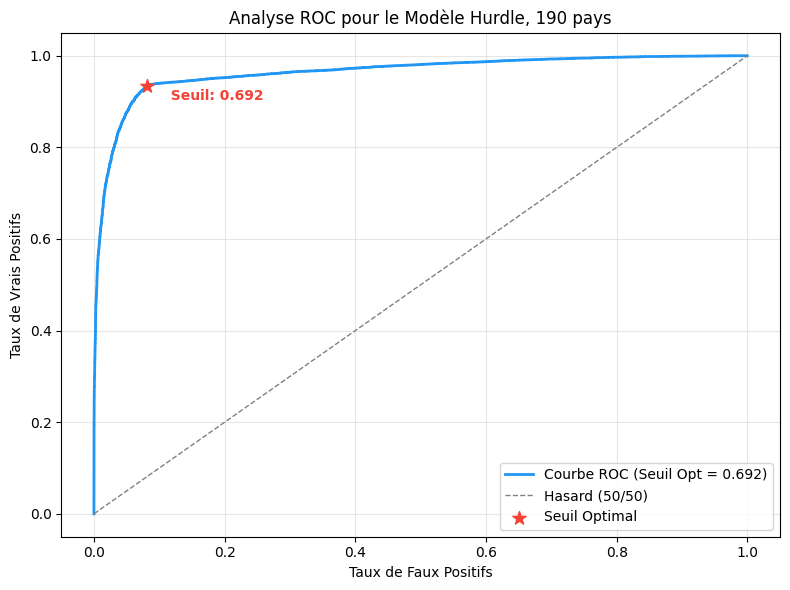

In [ ]:


# --- Visualisation de la courbe ROC ---
fig, ax = plt.subplots(figsize=(8, 6))

# Tracer la courbe ROC
ax.plot(fpr, tpr, color='#2196F3', lw=2, label=f'Courbe ROC (Seuil Opt = {optimal_threshold:.3f})')

# Tracer la ligne de hasard (random guess)
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Hasard (50/50)')

# Placer le point optimal
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color='#F44336', s=100, zorder=5, 
           label='Seuil Optimal', marker='*')

# Annotations
ax.annotate(f'  Seuil: {optimal_threshold:.3f}', 
            (fpr[optimal_idx], tpr[optimal_idx]), 
            xytext=(10, -10), textcoords='offset points', fontsize=10, color='#F44336', weight='bold')

ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title(f"Analyse ROC pour le Modèle Hurdle, {N_pays} pays")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"roc_curve_hurdle_{N_pays}_c.pdf", bbox_inches='tight')
plt.show()

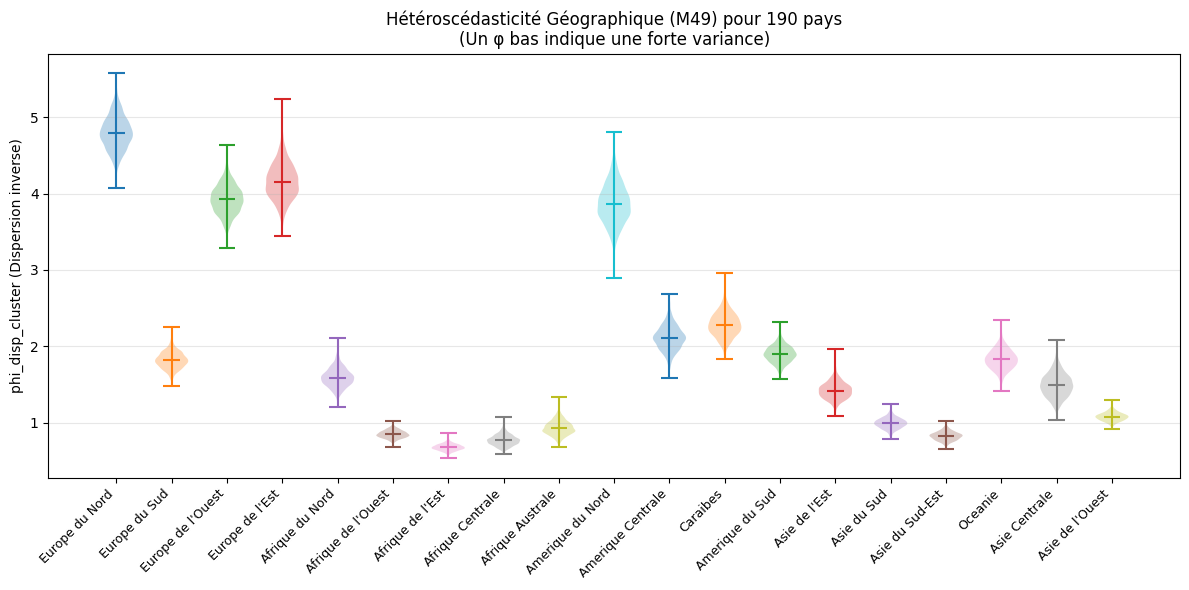

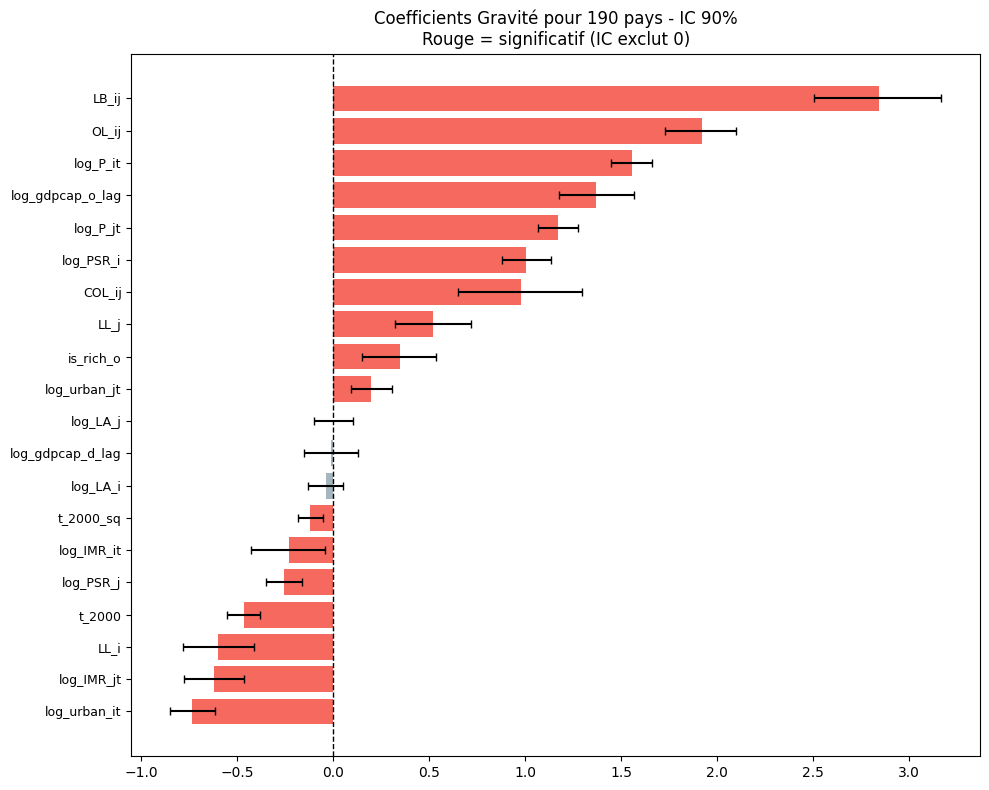

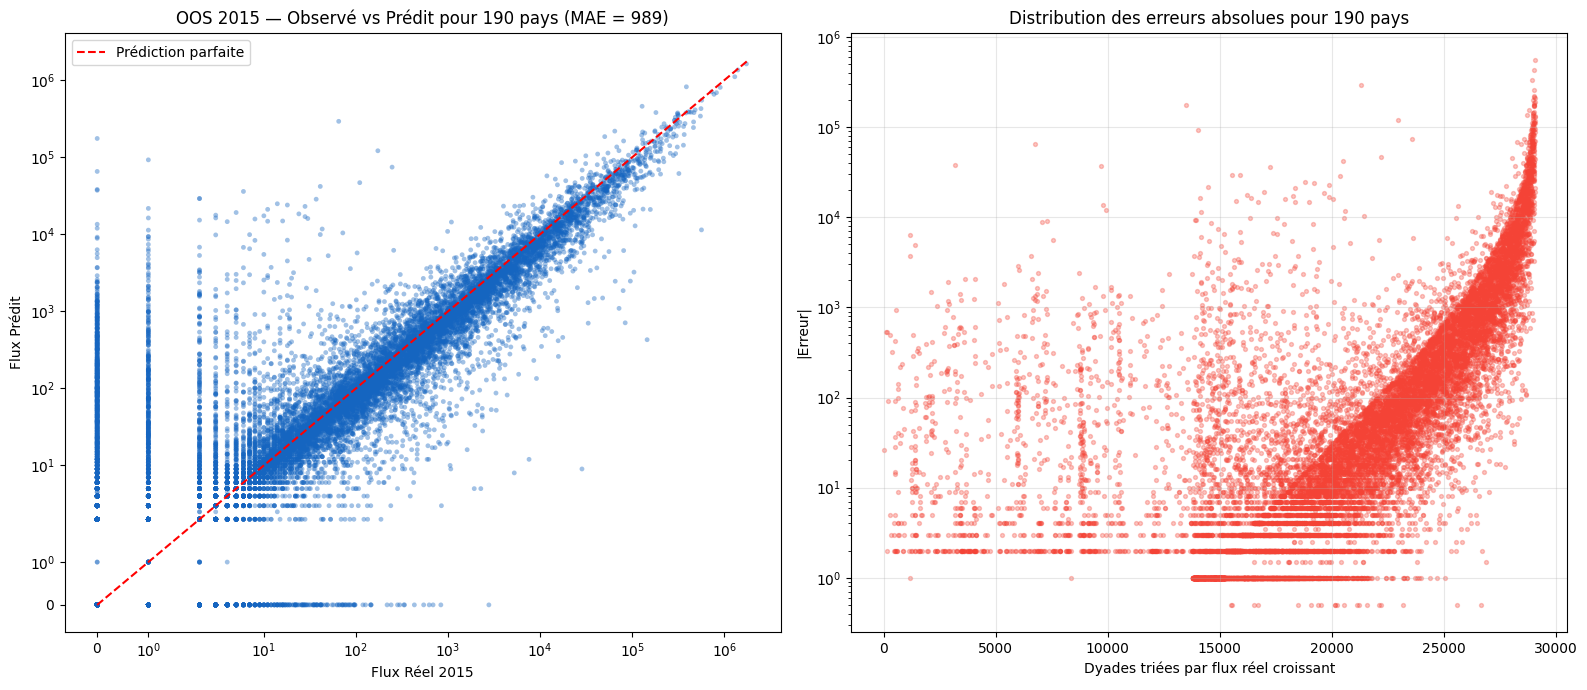

In [23]:
# Visualisations

"""
CONTINENT_NAMES = {1: 'Europe', 2:'Am. Nord', 3:'Afrique', 
                   4:'Am.Sud', 5:'Asie', 6: 'Océanie'}

fig, ax = plt.subplots(figsize=(10, 5))

for k in range(1, K_clusters + 1):
    draws_k = phi_disp_cluster[:, k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)

ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels([CONTINENT_NAMES.get(k, f'C{k}') for k in range(1, K_clusters + 1)])
ax.set_ylabel("phi_disp_cluster")
ax.set_title(f"Hétéroscédasticité Géographique — Dispersion inverse par Continent, pour {N_pays} pays")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"dispersion_cluster_{N_pays}_c.pdf", bbox_inches='tight')
plt.show()
"""

fig, ax = plt.subplots(figsize=(12, 6))

for k in range(1, K_clusters + 1):
    # Remplacement de sigma_cluster par phi_disp_cluster
    draws_k = phi_disp_cluster[:, k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)

ax.set_xticks(range(1, K_clusters + 1))

# Extraction dynamique des noms de sous-régions
x_labels = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'Cluster {k}') for k in range(1, K_clusters + 1)]
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)

ax.set_ylabel("phi_disp_cluster (Dispersion inverse)")
ax.set_title(f"Hétéroscédasticité Géographique (M49) pour {N_pays} pays\n(Un \u03c6 bas indique une forte variance)")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"dispersion_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()


beta_means = beta_grav.mean(axis=0)
beta_q05, beta_q95 = np.percentile(beta_grav, [5, 95], axis=0)

order = np.argsort(beta_means)

fig, ax = plt.subplots(figsize=(10, max(6, K_grav * 0.4)))

colors_coef = ['#F44336' if beta_q05[i] > 0 or beta_q95[i] < 0 else '#90A4AE' for i in order]

ax.barh(range(K_grav), beta_means[order], 
        xerr=[beta_means[order] - beta_q05[order], beta_q95[order] - beta_means[order]], 
        color=colors_coef, alpha=0.8, capsize=3)

ax.set_yticks(range(K_grav))
ax.set_yticklabels([X_VOL_COLS[i] for i in order], fontsize=9)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title(f"Coefficients Gravité pour {N_pays} pays - IC 90%\nRouge = significatif (IC exclut 0)")

plt.tight_layout()
plt.savefig(f"gravity_coefficients_{N_pays}_c.pdf", bbox_inches='tight')
plt.show()     

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=12, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit pour {N_pays} pays (MAE = {global_mae:,.0f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title(f"Distribution des erreurs absolues pour {N_pays} pays")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"prediction_scatter_{N_pays}_c.pdf", bbox_inches='tight')
plt.show()

Graphe de distribution des erreurs par dyades flux croissant: 
devrait ressembler à une bande horizontale diffuse. Tendance croissante pour les gros flux: l'erreur est positivement corrélée à la taille du flux, c'est problématique. 

In [24]:
# import numpy as np
# import pandas as pd
# import arviz as az

# # 1. Définition des paramètres de base (nomenclature ZTNB)
# base_params = [
#     'alpha_global', 'tau_alpha', 'beta_lag_m49',
#     'mu_intercept', 'tau_mu', 'rho_global_monitor',
#     'phi_disp_global', 'tau_phi_disp', 'tau_rho',
#     'phi_disp_cluster'
# ]

# posterior_dict = {}

# print(f"Formatage ArviZ : {N_CHAINS} chaînes de {N_DRAWS} itérations détectées.")

# # 2. Extraction stricte, transtypage et restructuration tridimensionnelle
# for param in base_params:
#     # Capture exhaustive indépendante de la syntaxe du compilateur Stan ('.' ou '[')
#     cols = [c for c in df_final.columns if c == param or c.startswith(f"{param}.") or c.startswith(f"{param}[")]
    
#     if not cols:
#         continue
        
#     # Transtypage forcé au niveau Pandas AVANT l'extraction NumPy pour garantir un float64 strict
#     data_matrix = df_final[cols].astype(float).values
    
#     # Redimensionnement dynamique
#     if len(cols) == 1:
#         posterior_dict[param] = data_matrix.reshape(N_CHAINS, N_DRAWS)
#     else:
#         posterior_dict[param] = data_matrix.reshape(N_CHAINS, N_DRAWS, len(cols))

# # 3. Instanciation de l'objet Inférence ArviZ
# idata = az.from_dict({"posterior": posterior_dict})

# # 4. Génération du résumé avec Intervalle de Densité Maximale (HDI) à 90%
# summary = az.summary(idata, hdi_prob=0.90)

# # Filtrage pour correspondre aux colonnes demandées (nomenclature exacte ArviZ)
# columns_to_display = ['mean', 'sd', 'hdi_5%', 'hdi_95%', 'r_hat', 'ess_bulk']
# print(summary[columns_to_display])

# # 5. Extraction des scalaires de diagnostic
# r_hat_val = summary['r_hat'].max()
# ess_bulk_val = summary['ess_bulk'].min()

# print(f"\nR_hat max    : {r_hat_val:.4f}")
# print(f"ESS_bulk min : {ess_bulk_val:.0f}")

# # 6. Décompte des divergences
# if 'divergent__' in df_final.columns:
#     div_total = pd.to_numeric(df_final['divergent__'], errors='coerce').sum()
#     print(f"Total divergences : {div_total:.0f}")


In [25]:

beta_means = beta_grav.mean(axis=0)
beta_q05   = np.percentile(beta_grav, 5,  axis=0)
beta_q95   = np.percentile(beta_grav, 95, axis=0)

print(f"{f'Variable, simul {N_pays} pays':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10}  {'Significatif?':>14}")
print("-" * 65)
for j, col in enumerate(X_VOL_COLS):
    sig = "✓ OUI" if (beta_q05[j] > 0 or beta_q95[j] < 0) else "  non"
    print(f"{col:<25} {beta_means[j]:>10.3f} {beta_q05[j]:>10.3f} {beta_q95[j]:>10.3f}  {sig:>14}")

Variable, simul 190 pays     Moyenne      IC 5%     IC 95%   Significatif?
-----------------------------------------------------------------
log_P_it                       1.559      1.449      1.664           ✓ OUI
log_P_jt                       1.171      1.065      1.277           ✓ OUI
log_PSR_i                      1.004      0.881      1.134           ✓ OUI
log_PSR_j                     -0.255     -0.352     -0.161           ✓ OUI
log_IMR_it                    -0.229     -0.428     -0.042           ✓ OUI
log_IMR_jt                    -0.624     -0.780     -0.466           ✓ OUI
log_urban_it                  -0.734     -0.852     -0.617           ✓ OUI
log_urban_jt                   0.195      0.090      0.304           ✓ OUI
log_LA_i                      -0.039     -0.133      0.051             non
log_LA_j                      -0.001     -0.101      0.105             non
LL_i                          -0.602     -0.781     -0.413           ✓ OUI
LL_j                           0.5

Figure 1: le Graal, ce serait des formes étalées horizontalement, basses sur l'axe des Y (modèle sûr de lui + volatilité basse). 
Figure 2: 